# Forward-kinematics tour on a UR5e

Load the UR5e URDF, walk through its kinematic tree, and compute end-effector poses and Jacobians from `tinyspatial`. This notebook is the gentlest possible introduction to the Python API.

**Prerequisites:** the `_tinyspatial` extension built via `cmake --preset=validation`, and `numpy` + `matplotlib`.

In [1]:
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path('..').resolve().parent
sys.path.insert(0, str(REPO / 'python'))
import tinyspatial as ts

## 1. Load the model

`build_model_from_urdf_file` walks the URDF, resolves inertias, and builds the `Model` — a stateless description of the robot's topology and joint types.

In [2]:
urdf = REPO / 'data' / 'robots' / 'ur5e.urdf'
model = ts.build_model_from_urdf_file(str(urdf))
print(f'name      : {model.name}')
print(f'njoints   : {model.njoints}')
print(f'nq        : {model.nq}   (configuration dimension)')
print(f'nv        : {model.nv}   (velocity dimension)')
print(f'parents   : {model.parent}')
for i, (jn, ln) in enumerate(zip(model.joint_names, model.link_names)):
    print(f'  [{i}] joint={jn:20s}  link={ln}')

name      : ur5e
njoints   : 6
nq        : 6   (configuration dimension)
nv        : 6   (velocity dimension)
parents   : [-1, 0, 1, 2, 3, 4]
  [0] joint=shoulder_pan_joint    link=shoulder_link
  [1] joint=shoulder_lift_joint   link=upper_arm_link
  [2] joint=elbow_joint           link=forearm_link
  [3] joint=wrist_1_joint         link=wrist_1_link
  [4] joint=wrist_2_joint         link=wrist_2_link
  [5] joint=wrist_3_joint         link=wrist_3_link


## 2. Compute forward kinematics

`forward_kinematics(model, q)` returns a list of 4×4 homogeneous matrices, one per joint, expressing each joint frame's pose in the world. The last entry is the wrist.

In [3]:
q_home = np.array([0.0, -np.pi/2, np.pi/2, -np.pi/2, -np.pi/2, 0.0])
poses = ts.forward_kinematics(model, q_home)
ee = poses[-1]
print('End-effector pose (4x4 homogeneous):')
print(np.round(ee, 4))
print(f'\nWrist position (m): {ee[:3, 3]}')

End-effector pose (4x4 homogeneous):
[[-0.     -1.      0.      0.233 ]
 [-0.     -0.     -1.      0.3254]
 [ 1.     -0.      0.      0.5547]
 [ 0.      0.      0.      1.    ]]

Wrist position (m): [0.23299999 0.3254     0.55470001]


## 3. Visualise the workspace

Sample random configurations within joint limits and plot the wrist positions. A simple way to *see* the reachable workspace.

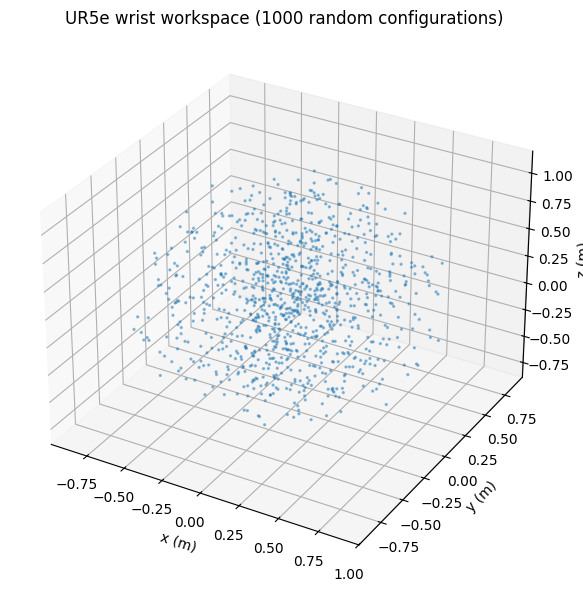

In [4]:
rng = np.random.default_rng(42)
n_samples = 1000
qs = rng.uniform(-np.pi, np.pi, size=(n_samples, model.nq))
wrist_positions = np.array([ts.forward_kinematics(model, q)[-1][:3, 3] for q in qs])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(wrist_positions[:, 0], wrist_positions[:, 1], wrist_positions[:, 2], s=2, alpha=0.4)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_title('UR5e wrist workspace (1000 random configurations)')
plt.tight_layout()
plt.show()

## 4. Geometric Jacobian

The Jacobian relates joint velocities to end-effector twist:
$$\dot{\xi} = J(q)\,\dot{q}$$
where $\dot{\xi} \in \mathbb{R}^6$ is angular-first $(\omega; v)$.

`compute_jacobian` returns it in the requested reference frame — `LOCAL` (body-fixed), `WORLD` (twist expressed in world coordinates), or `LOCAL_WORLD_ALIGNED` (origin at the body, axes aligned with world).

In [5]:
ee_link = model.njoints - 1
J_local = ts.compute_jacobian(model, q_home, ee_link, ts.LOCAL)
print(f'J_local shape: {J_local.shape}')
print(f'condition number: {np.linalg.cond(J_local):.2e}')
print(f'singular values: {np.linalg.svd(J_local, compute_uv=False)}')

J_local shape: (6, 6)
condition number: 8.25e+00
singular values: [1.79724063 1.44047574 1.         0.40698486 0.30866131 0.21782756]


## 5. Manipulability ellipsoid

The linear-velocity ellipsoid is $J_v J_v^\top$ (using the linear half of the Jacobian, rows 3..5 since we're angular-first). Its eigenvectors show the directions in which the wrist can move easily; its eigenvalues show the gains in those directions.

In [6]:
J_v = J_local[3:, :]            # linear rows (angular-first ordering)
M = J_v @ J_v.T                  # 3x3 manipulability metric
evals, evecs = np.linalg.eigh(M)
print('Manipulability eigenvalues (linear velocity gain^2):')
print(evals)
print('\nPrincipal direction (largest eigenvalue):')
print(evecs[:, -1])

Manipulability eigenvalues (linear velocity gain^2):
[0.07989025 0.11983084 0.41368048]

Principal direction (largest eigenvalue):
[-0.28759872  0.20684858 -0.93514739]


## What you learned

- `build_model_from_urdf_file` → `Model` (topology + inertias).
- `forward_kinematics(model, q)` → list of 4×4 world poses.
- `compute_jacobian(model, q, link_id, frame)` → 6×nv geometric Jacobian.

Next: see `02_rnea_vs_pinocchio.ipynb` for the dynamics side.

> **Course chapter:** `course/14_python_bindings/` for the binding-layer tour.